Regressione k-NN

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_diabetes
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_squared_error, r2_score


In [5]:
data = load_diabetes()
X = data.data
y = data.target

Xdf = pd.DataFrame(X, columns=data.feature_names)
display(Xdf)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641
...,...,...,...,...,...,...,...,...,...,...
437,0.041708,0.050680,0.019662,0.059744,-0.005697,-0.002566,-0.028674,-0.002592,0.031193,0.007207
438,-0.005515,0.050680,-0.015906,-0.067642,0.049341,0.079165,-0.028674,0.034309,-0.018114,0.044485
439,0.041708,0.050680,-0.015906,0.017293,-0.037344,-0.013840,-0.024993,-0.011080,-0.046883,0.015491
440,-0.045472,-0.044642,0.039062,0.001215,0.016318,0.015283,-0.028674,0.026560,0.044529,-0.025930


In [6]:
# scaliamo i dati

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [9]:
# utilizziamo diversi k per allenare il modello, poi faremo elbow method per vedere punto di flesso

k_range = range(1,20)
mse_values=[]

for k in k_range:
    knn_reg = KNeighborsRegressor(n_neighbors=k)
    knn_reg.fit(X_scaled, y)
    y_pred = knn_reg.predict(X_scaled)
    mse = mean_squared_error(y, y_pred)
    mse_values.append(mse)

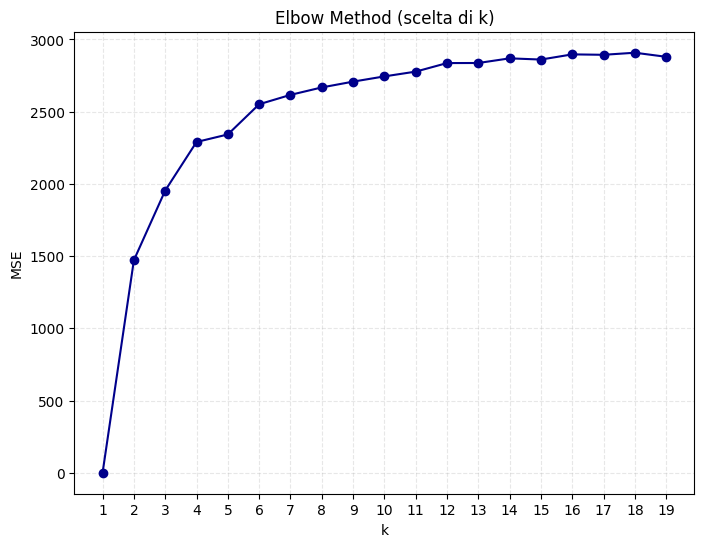

In [10]:
plt.figure(figsize=(8,6))
plt.plot(k_range, mse_values, marker="o", linestyle="-", color="darkblue")
plt.title("Elbow Method (scelta di k)")
plt.xlabel("k")
plt.ylabel("MSE")
plt.xticks(k_range)
plt.grid(linestyle="--", alpha=0.3)
plt.show()

In [13]:
best_k = 7

knn_final = KNeighborsRegressor(n_neighbors=best_k)
knn_final.fit(X_scaled, y)

y_pred_final = knn_final.predict(X_scaled)

mse_final = mean_squared_error(y, y_pred_final)
r2_final = r2_score(y, y_pred_final)

print(f"k:\t{best_k}\nMSE:\t{mse_final:.4f}\nR2:\t{r2_final:.4f}")

k:	7
MSE:	2616.4759
R2:	0.5588


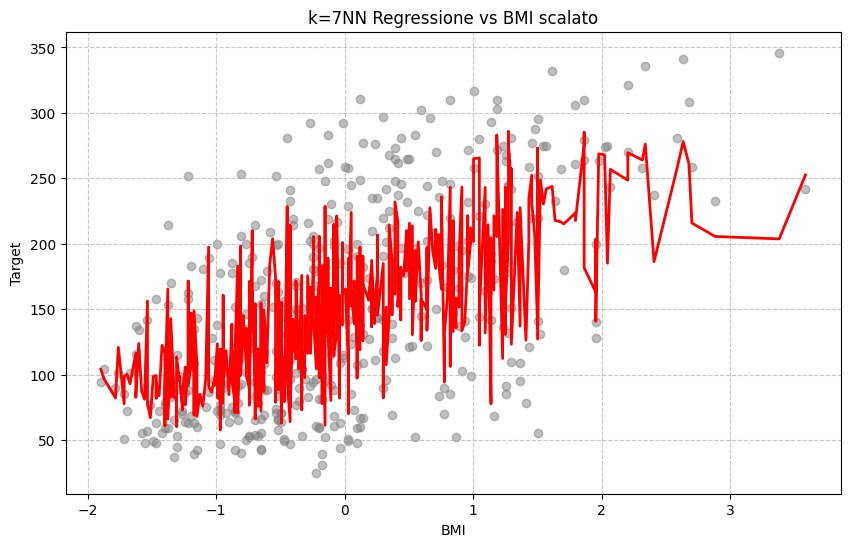

In [16]:
# scegliamo una singola feature per fare il plot del modello. 
# usiamo il BMI perché è la feature più significativa

feature_index = 2

sort_index = X_scaled[:, feature_index].argsort()
X_plot = X_scaled[sort_index, feature_index]
y_pred_plot = y_pred_final[sort_index]

plt.figure(figsize=(10,6))
# plot dei punti reali
plt.scatter(X_scaled[:, feature_index], y, color="grey", alpha=0.5, label="Real Data Points")
# plot dei punti predetti
plt.plot(X_plot, y_pred_plot, color="red", linewidth=2, label ="Regressione kNN")
plt.title(f"k={best_k}NN Regressione vs BMI scalato")
plt.xlabel("BMI")
plt.ylabel("Target")
plt.grid(True, linestyle="--", alpha=0.7)
plt.show()

In [17]:
# calcolo errore assoluto percentuale medio (mean absolute percentage error - mape)

import numpy as np
percentage_errors = np.abs((y- y_pred_final) /y)
mape = np.mean(percentage_errors) * 100

print(f"MAPE:\t{mape}%")

MAPE:	34.895743587789475%
